In [2]:
import ast
from collections import Counter
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
gigamidi = pd.read_csv("../../data/GigaMIDI/Final-Metadata-Extended-GigaMIDI-Dataset-updated.csv")

In [ ]:
# Helper to safely parse list-like strings
def parse_list(x):
    if pd.isna(x):
        return []
    try:
        return ast.literal_eval(x)
    except:
        return [x]

In [ ]:
# Extract genres (prioritize curated, fallback to scraped)
all_genres = []

for _, row in gigamidi.iterrows():
    genres = parse_list(row['music_styles_curated'])
    
    #if not genres:
    #    if pd.notna(row['music_style_scraped']):
    #        genres = [row['music_style_scraped']]
    
    all_genres.extend(genres)

# Count
genre_counts = Counter(all_genres)

# Convert to DataFrame for display
genre_df = pd.DataFrame(genre_counts.items(), columns=['genre', 'count'])
genre_df = genre_df.sort_values(by='count', ascending=False)

In [ ]:
display(genre_df)

,genre,count
0,classical,43916
2,game,21697
5,rock,1956
1,metal,1032
6,punk,642
11,pop,481
3,world,297
20,disco,295
15,country,244
18,jazz,191


In [ ]:
import numpy as np

total_loops = 0
loops_per_track = []
genre_loop_counts = Counter()

for _, row in gigamidi.iterrows():
    loop_tracks = parse_list(row['loop_track_idx'])
    num_loops = len(loop_tracks)
    
    total_loops += num_loops
    
    # Track distribution
    loops_per_track.append(num_loops)
    
    # Genre distribution
    genres = parse_list(row['music_styles_curated'])
    if not genres and pd.notna(row['music_style_scraped']):
        genres = [row['music_style_scraped']]
    
    for g in genres:
        genre_loop_counts[g] += num_loops

# Convert genre loop distribution to DataFrame
genre_loops_df = pd.DataFrame(genre_loop_counts.items(), columns=['genre', 'loop_count'])
genre_loops_df = genre_loops_df.sort_values(by='loop_count', ascending=False)

In [21]:
print("Total loops in dataset:", total_loops)

# Distribution over number of loops per file
loops_per_track = np.array(loops_per_track)
print("\nLoops per MIDI stats:")
print("Mean:", loops_per_track.mean())
print("Max:", loops_per_track.max())

Total loops in dataset: 9244220

Loops per MIDI stats:
Mean: 4.327376700318038
Max: 762


In [33]:
display(genre_loops_df[genre_loops_df['loop_count'] > 1000])

,genre,loop_count
3,classical,228252
11,game,180644
17,rock,100387
10,metal,78133
2,pop,73824
0,baroque,50184
6,renaissance,49858
1,traditional,30726
5,italian%2cfrench%2cspanish,29969
4,romantic,28553


In [36]:
gigamidi.columns

Index(['file_path', 'NOMML', 'num_tracks', 'TPQN', 'total_notes',
       'avg_note_duration', 'avg_velocity', 'min_velocity', 'max_velocity',
       'tempo', 'loop_track_idx', 'loop_instrument_type', 'loop_start',
       'loop_end', 'loop_duration_beats', 'loop_note_density',
       'NOMML_Instrument', 'Type',
       'instrument_category: drums-only: 0, all-instruments-with-drums: 1,no-drums: 2',
       'md5', 'music_styles_curated', 'music_style_scraped',
       'music_style_audio_text_Discogs', 'music_style_audio_text_Lastfm',
       'music_style_audio_text_Tagtraum', 'title', 'artist',
       'audio_text_matches_score', 'audio_text_matches_sid',
       'audio_text_matches_mbid', 'MIDI program number (expressive)',
       'instrument_group (expressive)', 'start_tick (expressive)',
       'end_tick (expressive)', 'duration_beats (expressive)',
       'note_density (expressive)', 'loopability (expressive)',
       'parsed_styles'],
      dtype='object')

In [48]:
print("Total MIDI files in dataset:", len(gigamidi))
# -----------------------------
# 1. Drop drums-only rows
# -----------------------------
filtered = gigamidi[
    gigamidi['instrument_category: drums-only: 0, all-instruments-with-drums: 1,no-drums: 2'] != 0
].copy()

print("After removing drums-only:", len(filtered))


# -----------------------------
# 2. Remove classical & jazz
# -----------------------------
def has_forbidden_genre(row):
    genres = parse_list(row['music_styles_curated'])
    for g in genres:
        g_lower = g.lower()
        if "classical" in g_lower or "jazz" in g_lower:
            return True
    return False

filtered = filtered[~filtered.apply(has_forbidden_genre, axis=1)]

print("After removing classical & jazz:", len(filtered))


# -----------------------------
# 3. Keep only rows with >=1 8-bar loop
# -----------------------------
TARGET_BEATS = 32.0
TOL = 0.5  # tolerance because floats

def has_8bar_loop(row):
    durations = parse_list(row['loop_duration_beats'])
    for d in durations:
        if abs(d - TARGET_BEATS) < TOL:
            return True
    return False

filtered = filtered[filtered.apply(has_8bar_loop, axis=1)]

print("After keeping 8-bar loops:", len(filtered))


columns_to_keep = [
    'file_path',
    'NOMML',
    'num_tracks',
    'TPQN',
    'total_notes',

    'loop_track_idx', 
    'loop_instrument_type', 
    'loop_start',
    'loop_end', 
    'loop_duration_beats', 
    'loop_note_density',

    'NOMML_Instrument',

    'md5',
    'music_styles_curated',
    'music_style_scraped'
]

filtered = filtered[columns_to_keep]

# -----------------------------
# Save result
# -----------------------------
output_path = "../../data/GigaMIDI/GigaMIDI-metadata-filtered-v1.csv"
filtered.to_csv(output_path, index=False)

print("Saved to:", output_path)

Total MIDI files in dataset: 2136218
After removing drums-only: 850306
After removing classical & jazz: 817407
After keeping 8-bar loops: 334722
Saved to: ../../data/GigaMIDI/GigaMIDI-metadata-filtered-v1.csv


In [3]:
filtered_df = pd.read_csv("../../data/GigaMIDI/GigaMIDI-metadata-filtered-v1.csv")

In [50]:
# Check distribution of loop durations

dur_counter = Counter()

for x in filtered_df['loop_duration_beats']:
    for d in parse_list(x):
        dur_counter[round(d)] += 1

print("Loop duration distribution (rounded):")
print(dict(sorted(dur_counter.items())))

Loop duration distribution (rounded):
{4: 1432933, 5: 9225, 6: 93953, 7: 56774, 8: 906094, 9: 13844, 10: 21631, 11: 7156, 12: 235328, 13: 2880, 14: 18766, 15: 44850, 16: 1017006, 17: 2878, 18: 34550, 19: 4258, 20: 161044, 21: 9525, 22: 12828, 23: 9477, 24: 430034, 25: 3582, 26: 14754, 27: 16081, 28: 239884, 29: 4056, 30: 61650, 31: 34912, 32: 1699658}


In [5]:
filtered_df.describe()

,num_tracks,TPQN,total_notes
count,334722.000000,334722.000000,3.347220e+05
mean,8.817864,484.502208,4.465165e+03
std,7.067181,429.464087,4.649182e+03
min,1.000000,4.000000,3.400000e+01
25%,4.000000,384.000000,1.939000e+03
50%,7.000000,480.000000,3.740000e+03
75%,11.000000,480.000000,5.895000e+03
max,198.000000,30720.000000,1.486725e+06


In [4]:
filtered_df.head(1)

,file_path,NOMML,num_tracks,TPQN,total_notes,loop_track_idx,loop_instrument_type,loop_start,loop_end,loop_duration_beats,loop_note_density,NOMML_Instrument,md5,music_styles_curated,music_style_scraped
0,./Final_GigaMIDI_V1.1_Final/training-V1.1-80%/...,"[4, 2]",2,192.0,2824,"[0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1]","['Piano', 'Piano', 'Piano', 'Piano', 'Piano', ...","[1536, 13824, 32256, 36864, 6528, 47232, 1152,...","[2304, 19968, 38400, 42240, 12288, 50688, 7296...","[4.0, 32.0, 32.0, 28.0, 30.0, 18.0, 32.0, 4.0,...","[3.0, 3.09375, 10.3125, 10.357142857142858, 3....","['Piano', 'Piano']",277be017df058172b080182b81df6e9d,NaN,NaN


In [3]:
df = pd.read_csv("../../data/GigaMIDI/filtered_loops_v1/enriched_manifest.csv")

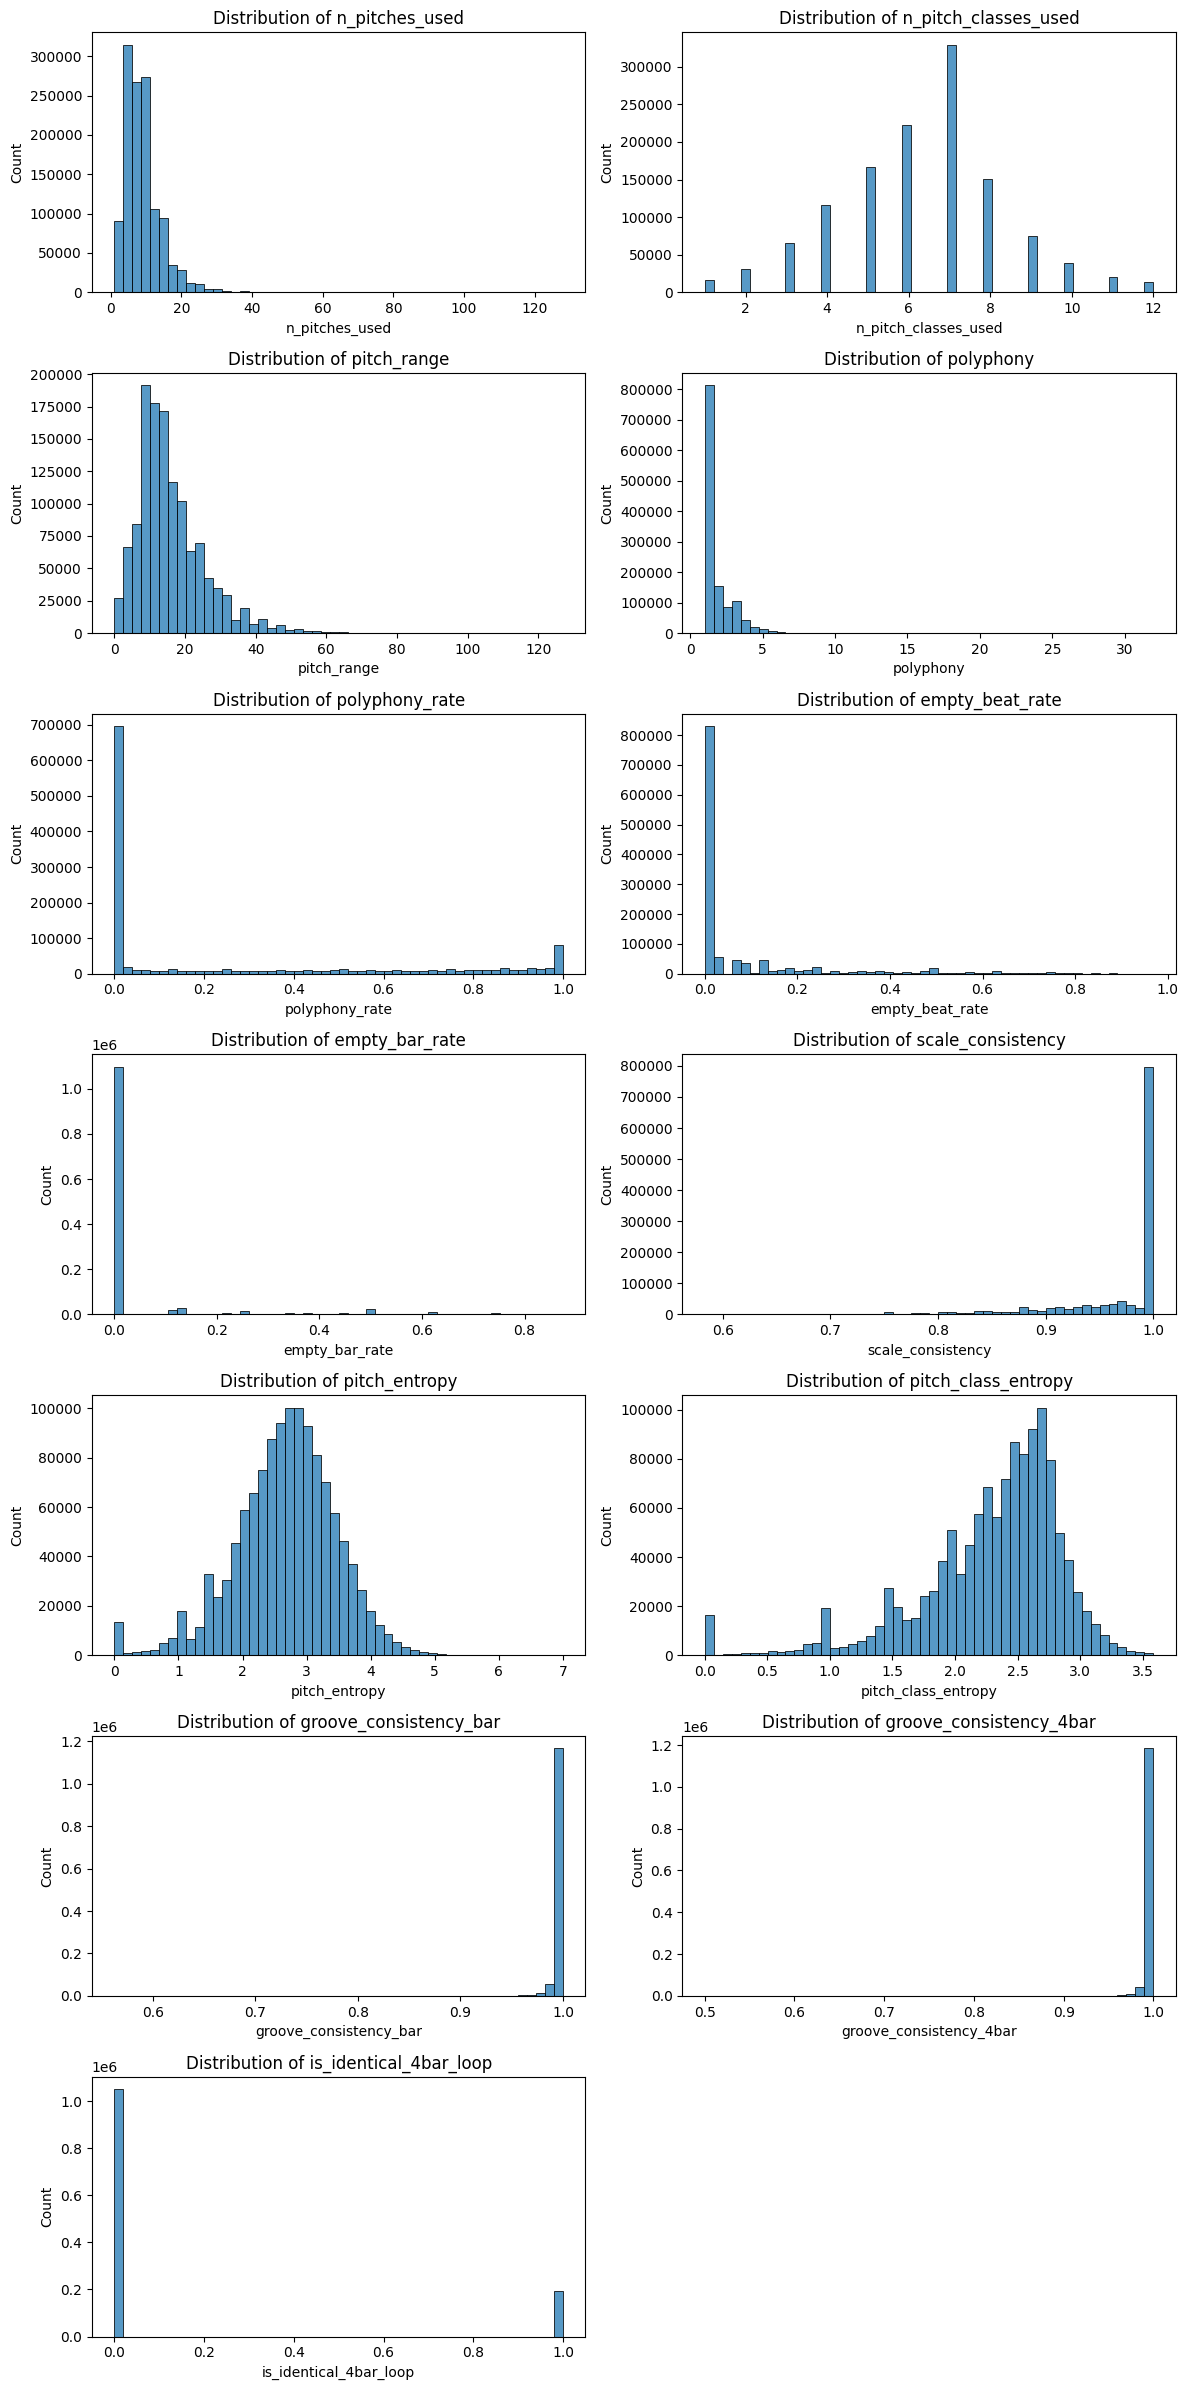


Metric statistics:
  n_pitches_used:
    count: 1245574.0000
    mean: 9.1331
    std: 5.1190
    min: 1.0000
    25%: 6.0000
    50%: 8.0000
    75%: 11.0000
    max: 128.0000
  n_pitch_classes_used:
    count: 1245574.0000
    mean: 6.3221
    std: 2.0501
    min: 1.0000
    25%: 5.0000
    50%: 7.0000
    75%: 7.0000
    max: 12.0000
  pitch_range:
    count: 1245574.0000
    mean: 16.1227
    std: 9.4617
    min: 0.0000
    25%: 10.0000
    50%: 14.0000
    75%: 20.0000
    max: 127.0000
  polyphony:
    count: 1245574.0000
    mean: 1.6760
    std: 1.0789
    min: 1.0000
    25%: 1.0000
    50%: 1.0003
    75%: 2.0079
    max: 31.9829
  polyphony_rate:
    count: 1245574.0000
    mean: 0.2609
    std: 0.3627
    min: 0.0000
    25%: 0.0000
    50%: 0.0002
    75%: 0.5312
    max: 1.0000
  empty_beat_rate:
    count: 1245574.0000
    mean: 0.0826
    std: 0.1682
    min: 0.0000
    25%: 0.0000
    50%: 0.0000
    75%: 0.0909
    max: 0.9688
  empty_bar_rate:
    count: 1245574.000

In [4]:
metrics_to_plot = ["n_pitches_used", 
                   "n_pitch_classes_used", 
                   "pitch_range", 
                   "polyphony", 
                   "polyphony_rate", 
                   "empty_beat_rate", 
                   "empty_bar_rate", 
                   "scale_consistency", 
                   "pitch_entropy", 
                   "pitch_class_entropy", 
                   "groove_consistency_bar", 
                   "groove_consistency_4bar", 
                   "is_identical_4bar_loop"]

plt.figure(figsize=(12, 24))
for i, col in enumerate(metrics_to_plot, 1):
    plt.subplot(7, 2, i)
    sns.histplot(df[col].dropna(), kde=False, bins=50)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

print("\nMetric statistics:")
for col in metrics_to_plot:
    if col in df.columns:
        s = df[col].describe()
        print(f"  {col}:")
        for stat in ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]:
            if stat in s.index:
                print(f"    {stat}: {s[stat]:.4f}")